In [63]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [64]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [65]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [66]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [67]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [68]:
rate_col = "Liver Rate"

In [69]:
design_matrix_otrain[rate_col].mean()

0.12204264705882345

In [70]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

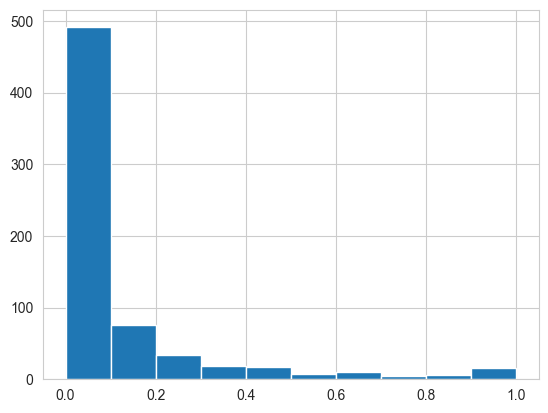

In [71]:
design_matrix_train[rate_col].hist(bins=10)

In [72]:
design_matrix_train['group'].value_counts()

group
1    498
2    182
Name: count, dtype: int64

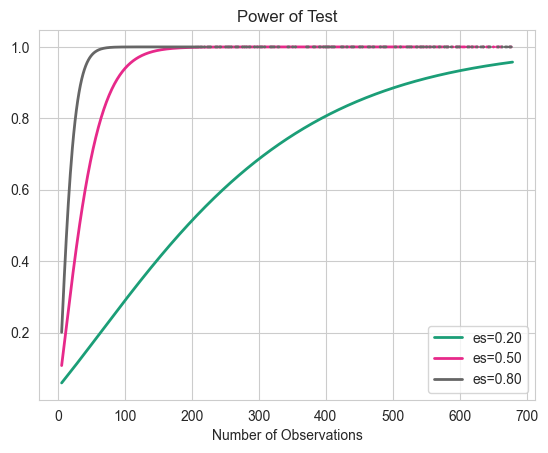

In [73]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [74]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [75]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [76]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [77]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

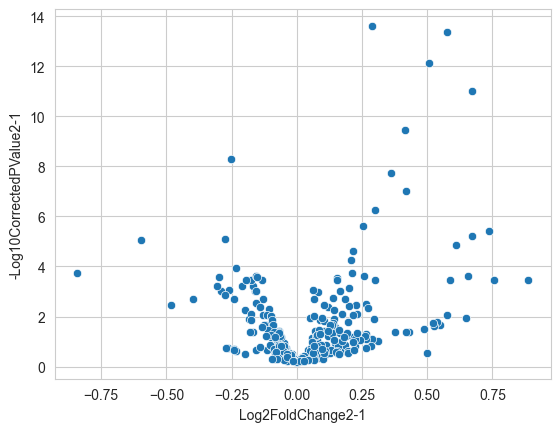

In [78]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [79]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
72,Q15582,BGH3_HUMAN,1.051950,12.200281,11.910480,0.483838,0.354772,0.289800,1.297921e-16,182,...,12.189729,12.181741,11.650090,12.185936,12.036681,10.988674,11.564865,12.850858,11.887155,12.531832
162,P01833,PIGR_HUMAN,1.164439,11.660611,11.084119,0.953629,0.732435,0.576491,4.422951e-16,182,...,10.815594,10.893127,10.640803,11.654822,11.584860,11.376154,9.675695,11.884602,10.664987,12.582187
183,P05362,ICAM1_HUMAN,1.045834,10.053956,9.548419,0.931374,0.653312,0.505537,1.161408e-14,182,...,9.423490,9.542654,9.365688,10.190797,9.319579,9.293526,9.317505,9.946124,9.173564,10.092941
154,P01033,TIMP1_HUMAN,1.101704,10.823530,10.150066,1.205923,0.965736,0.673464,2.040525e-13,182,...,11.305144,9.690175,10.005689,11.112195,9.291888,10.080163,9.175368,10.305271,10.987082,9.923244
132,P00338,LDHA_HUMAN,0.835918,10.260426,9.846361,0.843075,0.622356,0.414065,9.554641e-12,182,...,10.226076,9.818765,9.666478,11.790201,9.947840,9.874539,9.184632,10.825064,11.096588,9.594872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,P48740,MASP1_HUMAN,0.002635,11.658111,11.660214,0.456720,0.471571,-0.002103,9.586696e-01,182,...,12.130347,11.902136,11.121653,11.906331,11.885944,11.959713,11.876585,12.010289,11.066397,12.075987
257,Q15166,PON3_HUMAN,0.002638,9.088964,9.086689,1.019302,0.898253,0.002276,9.775579e-01,182,...,9.144067,9.993320,9.073226,10.225316,8.795877,9.101333,8.749668,9.214784,9.602020,8.874613
41,P21333,FLNA_HUMAN,0.005210,9.959979,9.955395,1.591458,1.707927,0.004583,9.748836e-01,182,...,10.450650,11.005217,10.647641,12.768931,9.830465,11.048502,9.017430,10.666118,4.240518,11.598495
27,Q08380,LG3BP_HUMAN,0.001166,11.334622,11.335616,0.786899,0.769364,-0.000994,9.881926e-01,182,...,11.357729,11.085795,11.136547,10.668692,10.507697,11.144803,11.230881,12.095545,10.870497,13.928697


In [80]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [81]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [82]:
protein_columns = training_data.columns.to_list()

In [83]:
len(protein_columns)

287

In [84]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [86]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.6148451730418943,
 0.5529149159663865,
 0.7646485517133835,
 0.7170611407378146,
 0.7858620273443501)

In [ ]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [61]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [62]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
ITA2B_HUMAN,1.023354,1.069176,0.392098,0.828209
IL1AP_HUMAN,0.953670,0.803967,0.452871,0.736836
TBB5_HUMAN,0.796275,0.785261,0.620848,0.734128
LYAM1_HUMAN,0.473797,0.789271,0.871426,0.711498
CD5L_HUMAN,0.525714,0.603408,0.791021,0.640048
...,...,...,...,...
PI16_HUMAN,0.061791,0.024332,0.013897,0.033340
QSOX1_HUMAN,0.021745,0.015219,0.060389,0.032451
MYL6_HUMAN,0.017400,0.056070,0.021060,0.031510


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

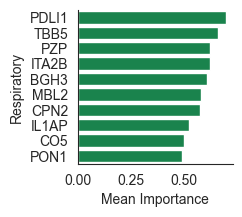

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Liver"

In [34]:
feature_importance_results.to_csv(
    "liver_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/liver_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/liver_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
